# Generative Time Series Modeling with Neural SDEs

This notebook explores modeling predator-prey dynamics using stochastic differential equations. We first review the dataset and the deterministic baseline with Neural ODEs, then later introduce Neural SDEs to capture stochasticity in the data.

---

In [1]:
# Imports
!pip install diffrax equinox optax --quiet
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

# Load data
data_path = "/kaggle/input/lynxhare/LH_data (1).npy"
LH_data = np.load(data_path, allow_pickle=True)
LH_data = jnp.array(LH_data)  # convert to JAX array

# Basic stats
num_entries = LH_data.shape[0]
num_features = LH_data.shape[1] if len(LH_data.shape) > 1 else 1
print(LH_data)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 4.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 6.0 MB/s eta 0:00:00
[[1845.     19.58   30.09]
 [1846.     19.6    45.15]
 [1847.     19.61   49.15]
 [1848.     11.99   39.52]
 [1849.     28.04   21.23]
 [1850.     58.      8.42]
 [1851.     74.6     5.56]
 [1852.     75.09    5.08]
 [1853.     88.48   10.17]
 [1854.     61.28   19.6 ]
 [1855.     74.67   32.91]
 [1856.     88.06   34.38]
 [1857.     68.51   29.59]
 [1858.     32.19   21.3 ]
 [1859.     12.64   13.69]
 [1860.     21.49    7.65]
 [1861.     30.35    4.08]
 [1862.      2.18    4.09]
 [1863.    152.65   14.33]
 [1864.    148.36   38.22]
 [1865.     85.81   60.78]
 [1866.     41.41   70.77]
 [1

---

# The Dataset

| Feature | Description |
|---------|-------------|
| Source | Classic Lynx-Hare predation pelts data |
| Structure | 30 time steps (Years) with three columns: `[Year, Hare, Lynx]` |
| Key Feature | Strong, coupled cyclic behavior (Lotka-Volterra dynamics) |
| Challenge | Sparse and noisy observations; deterministic models cannot capture all variability |

The dataset provides a clear cyclic pattern with delayed predator-prey interactions. Modeling requires capturing the smooth cycle (trend) while acknowledging inherent noise.

---

Number of entries: 30
Number of features per entry (Year, Hare, Lynx): 3
------------------------------
             Year      Hare      Lynx
Mean values: [1859.5001     47.627      25.611668]
Standard deviation: [ 8.655441 39.01402  19.50225 ]
Minimum values: [1845.      2.18    4.08]
Maximum values: [1874.    152.65   72.77]
------------------------------


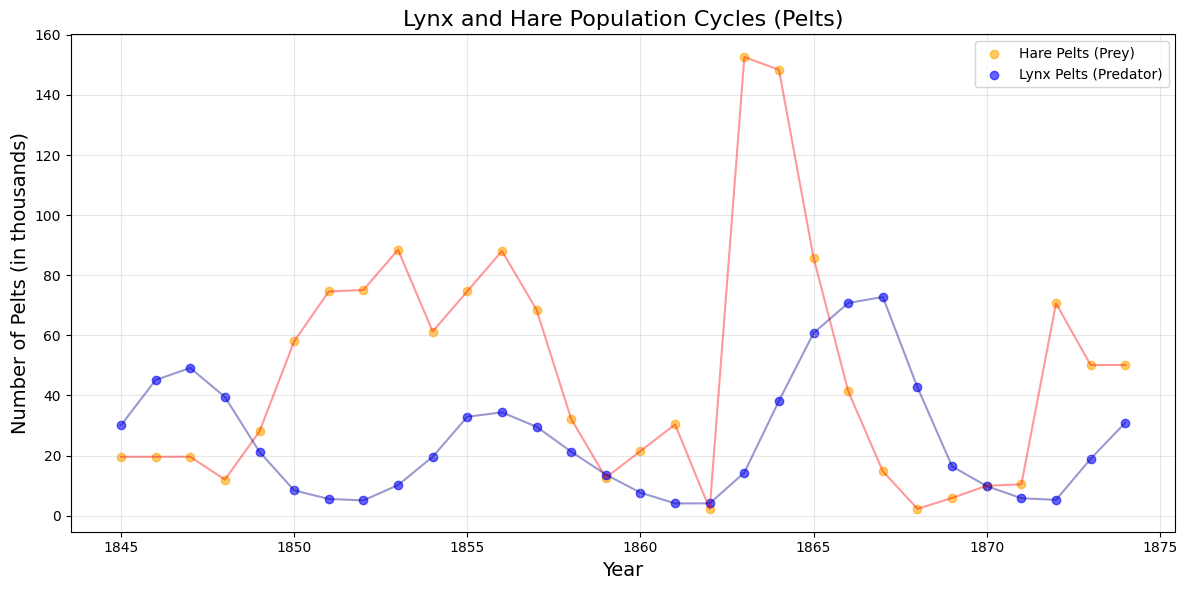

In [3]:
ts = LH_data[:, 0]  # Years
hare_population = LH_data[:, 1]  # Hare population (pelts)
lynx_population = LH_data[:, 2]  # Lynx population (pelts)

# Calculate statistics (including the year column)
# mean_values[0] is mean year, mean_values[1] is mean hare, mean_values[2] is mean lynx
mean_values = jnp.mean(LH_data, axis=0)
std_values = jnp.std(LH_data, axis=0)
min_values = jnp.min(LH_data, axis=0)
max_values = jnp.max(LH_data, axis=0)

print("Number of entries:", num_entries)
print("Number of features per entry (Year, Hare, Lynx):", num_features)
print("-" * 30)
# Updated labels to reflect the [Year, Hare, Lynx] order
print("             Year      Hare      Lynx")
print("Mean values:", mean_values)
print("Standard deviation:", std_values)
print("Minimum values:", min_values)
print("Maximum values:", max_values)
print("-" * 30)


# Plot raw data: Lynx and Hare populations
plt.figure(figsize=(12, 6))

# Plot Hare population (Column 1 / Index 1) - Typically shown as the prey
plt.scatter(ts, hare_population, color='orange', alpha=0.6, label='Hare Pelts (Prey)')
plt.plot(ts, hare_population, color='red', alpha=0.4)

# Plot Lynx population (Column 2 / Index 2) - Typically shown as the predator
plt.scatter(ts, lynx_population, color='blue', alpha=0.6, label='Lynx Pelts (Predator)')
plt.plot(ts, lynx_population, color='darkblue', alpha=0.4)


plt.title("Lynx and Hare Population Cycles (Pelts)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Pelts (in thousands)", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

  0%|          | 2/3000 [00:07<2:29:17,  2.99s/it]

Epoch 0, Loss: 0.091931


 17%|█▋        | 501/3000 [01:55<10:35,  3.93it/s]

Epoch 500, Loss: 0.043512


 33%|███▎      | 1001/3000 [04:10<09:02,  3.69it/s]

...

 67%|██████▋   | 2001/3000 [08:44<04:31,  3.68it/s]

Epoch 2000, Loss: 0.032476


 83%|████████▎ | 2501/3000 [11:05<02:17,  3.63it/s]

Epoch 2500, Loss: 0.030130


100%|██████████| 3000/3000 [13:22<00:00,  3.74it/s]


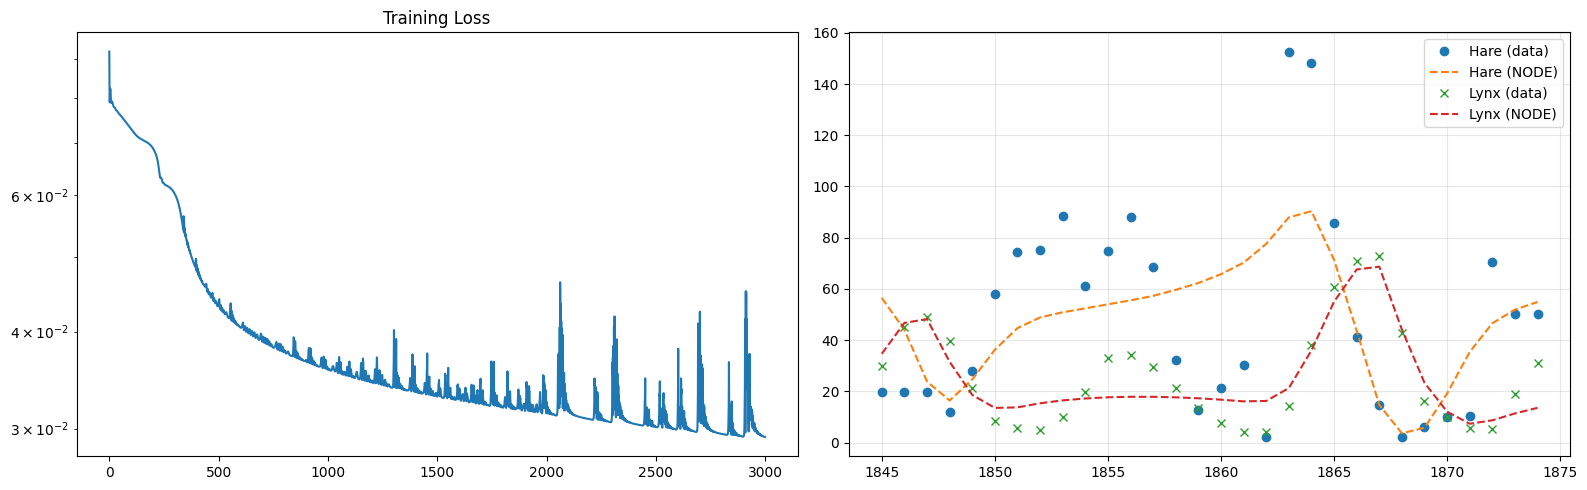

In [4]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import diffrax
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. Data Preparation and Normalization ---

# Example: LH_data = np.array([...]) # 30 rows [Year, Hare, Lynx]
t_raw = LH_data[:, 0]
hare_population = LH_data[:, 1]
lynx_population = LH_data[:, 2]

# Normalize time to [0,1]
t_eval = (t_raw - t_raw[0]) / (t_raw[-1] - t_raw[0])

# Max scaling
max_hare = jnp.max(hare_population)
max_lynx = jnp.max(lynx_population)

hare_norm = hare_population / max_hare
lynx_norm = lynx_population / max_lynx

y_true = jnp.stack([hare_norm, lynx_norm], axis=1)
initial_y0 = y_true[0]


# --- 2. Trainable Initial Condition ---
class TrainableY0(eqx.Module):
    y0: jnp.ndarray

    def __init__(self, y0):
        self.y0 = y0

trainable_y0 = TrainableY0(initial_y0)


# --- 3. Neural ODE with Lotka–Volterra Backbone ---

key = jax.random.PRNGKey(0)

class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP
    A: jnp.ndarray

    def __init__(self, key):
        k1, _ = jax.random.split(key)

        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=2,
            width_size=64,   # Bigger MLP
            depth=3,         # Deeper MLP
            activation=jax.nn.tanh,
            key=k1
        )

        # Linear LV backbone
        self.A = jnp.array([[0.5, -0.6],
                            [0.6, -0.5]])

    def __call__(self, t, y, args=None):
        return self.A @ y + self.mlp(y)

ode_func = ODEFunc(key)
trainable_modules = (ode_func, trainable_y0)


# --- 4. Optimizer ---
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(trainable_modules, eqx.is_array))


# --- 5. Neural ODE Solver ---
ts_dense = jnp.linspace(t_eval[0], t_eval[-1], 300)
idx = jnp.linspace(0, 299, len(t_eval)).astype(int)  # map dense to observation points

@eqx.filter_jit
def solve_ode(ode_func, trainable_y0, ts):
    term = diffrax.ODETerm(ode_func)

    sol = diffrax.diffeqsolve(
        term,
        diffrax.Tsit5(),          # Tsit5 solver
        t0=ts[0],
        t1=ts[-1],
        dt0=0.01,
        y0=trainable_y0.y0,
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(rtol=1e-5, atol=1e-7),
        max_steps=100_000,
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
    )
    return sol.ys


# --- 6. Loss Function ---
@eqx.filter_value_and_grad
def loss_fn_with_grad(trainable_modules, y_true):
    ode_func, trainable_y0 = trainable_modules

    y_dense = solve_ode(ode_func, trainable_y0, ts_dense)
    y_pred = y_dense[idx]

    data_loss = jnp.mean((y_pred - y_true) ** 2)
    dy_pred = y_pred[1:] - y_pred[:-1]
    dy_true = y_true[1:] - y_true[:-1]
    deriv_loss = jnp.mean((dy_pred - dy_true) ** 2)

    return data_loss + 0.1 * deriv_loss


@eqx.filter_jit
def update(trainable_modules, opt_state, y_true):
    loss, grads = loss_fn_with_grad(trainable_modules, y_true)

    updates, opt_state = optimizer.update(
        grads,
        opt_state,
        params=eqx.filter(trainable_modules, eqx.is_array),
    )
    trainable_modules = eqx.apply_updates(trainable_modules, updates)
    return trainable_modules, opt_state, loss


# --- 7. Training Loop ---
loss_history = []
num_epochs = 3000

for step in tqdm(range(num_epochs)):
    trainable_modules, opt_state, loss = update(trainable_modules, opt_state, y_true)
    loss_history.append(float(loss))
    if step % 500 == 0:
        print(f"Epoch {step}, Loss: {loss:.6f}")

ode_func_trained, trainable_y0_trained = trainable_modules


# --- 8. Prediction & Plotting ---
y_dense = solve_ode(ode_func_trained, trainable_y0_trained, ts_dense)
y_fit = y_dense[idx]

y_obs = jax.device_get(y_true)
y_fit = jax.device_get(y_fit)

# Denormalize
hare_obs = y_obs[:, 0] * max_hare
hare_fit = y_fit[:, 0] * max_hare
lynx_obs = y_obs[:, 1] * max_lynx
lynx_fit = y_fit[:, 1] * max_lynx

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(loss_history)
axes[0].set_yscale("log")
axes[0].set_title("Training Loss")

axes[1].plot(t_raw, hare_obs, "o", label="Hare (data)")
axes[1].plot(t_raw, hare_fit, "--", label="Hare (NODE)")
axes[1].plot(t_raw, lynx_obs, "x", label="Lynx (data)")
axes[1].plot(t_raw, lynx_fit, "--", label="Lynx (NODE)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# Improved Neural ODE Modeling (Physics-Informed)

- **Objective:** Learn the dominant deterministic predator–prey dynamics

- **Approach:**  
  - Autonomous Neural ODE with a **Lotka–Volterra–style linear backbone**  
  - MLP learns nonlinear corrections to oscillatory dynamics  
  - Time normalized to \([0, 1]\) for stable integration  
  - Dense-time integration with sparse observation loss  
  - Combined loss: trajectory MSE + derivative (velocity) matching  

| Characteristic | Description | Observed Performance |
|----------------|-------------|--------------------|
| Architecture | Linear LV backbone + 3-layer MLP (Width=64, Depth=3) | Preserves oscillatory structure and allows more complex dynamics |
| Inputs | Hare, Lynx populations | Autonomous dynamics; no explicit time input |
| Solver | Adaptive ODE solver (Tsit5) | Stable integration over normalized time, modern replacement for Dopri5 |
| Training | 3000 epochs, LR=1e-3 | Loss reduced |
| Fit Quality | Deterministic trajectory fit | Improved phase and amplitude alignment over baseline |

- **Conclusion:**
    - The physics-informed Neural ODE with a larger MLP and modern solver captures the **dominant cyclic structure** of the lynx–hare system more accurately than a smaller, baseline NODE. Remaining discrepancies are consistent with **stochastic effects and measurement noise**, motivating the extension to Neural SDEs for explicit uncertainty modeling.
---

Starting SDE Training on 5 Synthetic Datasets...
(Compilation may take 1-2 minutes on first step)
Epoch 0, NLL: 2.579967
Epoch 100, NLL: 0.849090
Epoch 200, NLL: 0.879461
Epoch 300, NLL: 0.855984
Epoch 400, NLL: 0.733858
Epoch 500, NLL: 0.569420
Epoch 600, NLL: 0.589906
Epoch 700, NLL: 0.546276
Epoch 800, NLL: 0.740918
Epoch 900, NLL: 0.544174
Epoch 1000, NLL: 0.461349
Generating predictions with 100 rollouts...


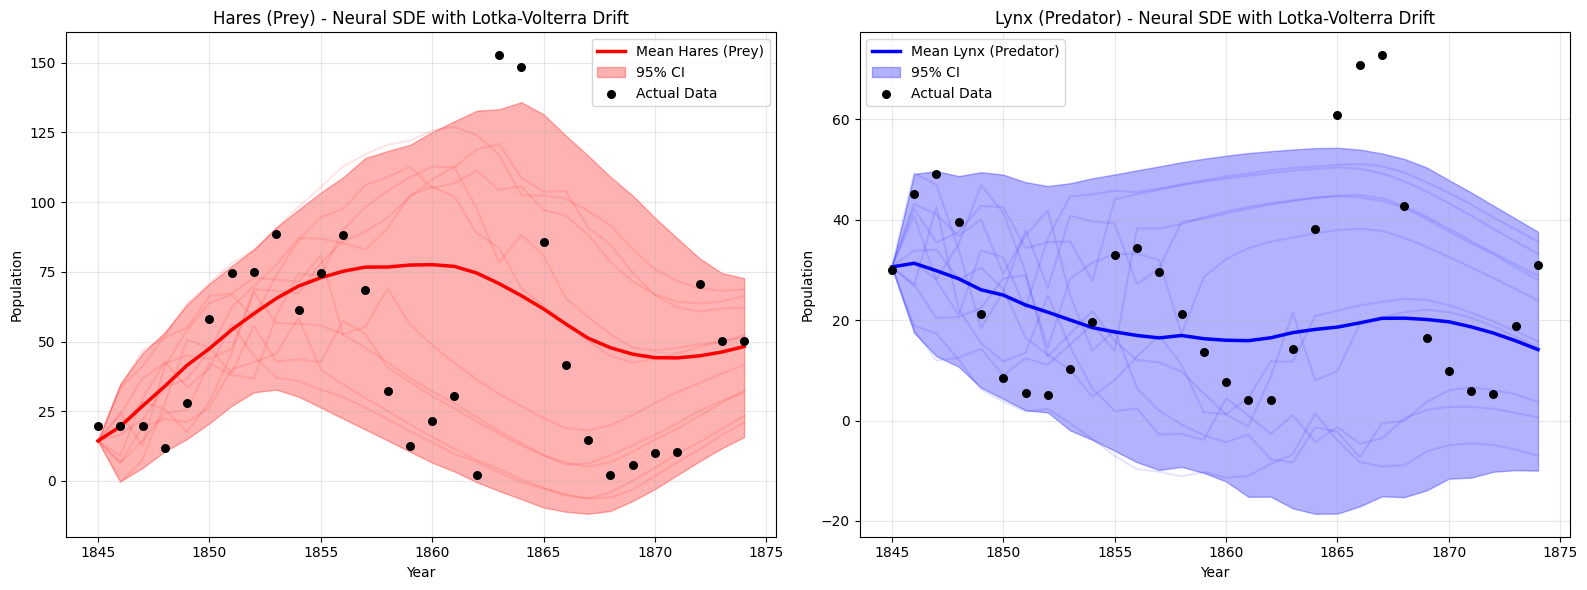


Training complete!
Model trained on 5 synthetic datasets
Latent dimension: 4
Training rollouts: 20, Prediction rollouts: 100
Final NLL: 0.461349


In [3]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
import lineax as lx
import matplotlib.pyplot as plt

# -----------------------------
# 1. Data Loading & Preprocessing
# -----------------------------
ts = LH_data[:, 0]
ys = LH_data[:, 1:3]  # [Hare, Lynx]

# Normalize
ts_mean, ts_std = ts.mean(), ts.std()
ys_mean, ys_std = ys.mean(axis=0), ys.std(axis=0)

ts_norm = (ts - ts_mean) / ts_std
ys_norm = (ys - ys_mean) / ys_std

# -----------------------------
# 2. Config
# -----------------------------
LATENT_SIZE = 4           # Keep original size
HIDDEN_SIZE = 32          # Keep original size
MLP_HIDDEN = 64           # Keep original size
LEARNING_RATE = 1e-3
NUM_SAMPLES = 100         # Increased rollouts for predictions
K_for_loss = 20           # Increased rollouts for training
EPOCHS = 1000
key = jax.random.PRNGKey(42)
eps = 1e-6              

# -----------------------------
# 3. Generate 5 Synthetic Datasets
# -----------------------------
synthetic_datasets = []
for i in range(5):
    key, subkey = jax.random.split(key)
    # Add noise to initial conditions (±10%)
    y0_noise = ys_norm[0] * (1 + 0.1 * jax.random.normal(subkey, (2,)))
    # Add noise to entire trajectory (simulating different conditions)
    noise = 0.05 * jax.random.normal(subkey, ys_norm.shape)
    ys_synthetic = ys_norm + noise
    ys_synthetic = ys_synthetic.at[0].set(y0_noise)
    synthetic_datasets.append(ys_synthetic)

synthetic_datasets = jnp.stack(synthetic_datasets)  # (5, seq_len, 2)

# -----------------------------
# 4. Model Components (LOTKA-VOLTERRA DRIFT)
# -----------------------------
class GRUEncoder(eqx.Module):
    gru_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    def __init__(self, input_size, hidden_size, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.gru_cell = eqx.nn.GRUCell(input_size, hidden_size, key=k1)
        self.linear_out = eqx.nn.Linear(hidden_size, latent_size, key=k2)
    def __call__(self, ys):
        h = jnp.zeros(self.gru_cell.hidden_size)
        def body(h, y):
            h_new = self.gru_cell(y, h)
            return h_new, None
        h_final, _ = jax.lax.scan(body, h, ys)
        return self.linear_out(h_final)

class LotkaVolterraDrift(eqx.Module):
    """Lotka-Volterra equations with small MLP correction"""
    A: jnp.ndarray  # Interaction matrix
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        # Initialize Lotka-Volterra matrix (predator-prey structure)
        self.A = jnp.array([[0.5, -0.3],   # Prey: growth - predation
                            [0.2, -0.4]])   # Predator: predation benefit - death
        # Expand to full latent size
        full_A = jnp.zeros((latent_size, latent_size))
        full_A = full_A.at[:2, :2].set(self.A)
        self.A = full_A
        # Small MLP correction
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 3, jax.nn.tanh, key=k2)
        
    def __call__(self, t, z, args):
        # Lotka-Volterra + small MLP correction
        return self.A @ z + 0.05 * self.mlp(z)

class LatentDiffusion(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 3, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        sigma_latent = jax.nn.softplus(self.mlp(z)) 
        return lx.DiagonalLinearOperator(sigma_latent + 1e-6)

class Decoder(eqx.Module):
    linear: eqx.nn.Linear
    log_obs_noise: jnp.ndarray 
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.linear = eqx.nn.Linear(latent_size, 2, key=k1)
        self.log_obs_noise = jnp.array(-2.0) 
    def __call__(self, z):
        return self.linear(z)
    def obs_noise(self):
        return jnp.exp(self.log_obs_noise)

class LatentSDE(eqx.Module):
    encoder: GRUEncoder
    drift: LotkaVolterraDrift
    diffusion: LatentDiffusion
    decoder: Decoder
    def __init__(self, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.encoder = GRUEncoder(2, HIDDEN_SIZE, LATENT_SIZE, k1)
        self.drift = LotkaVolterraDrift(LATENT_SIZE, k2)
        self.diffusion = LatentDiffusion(LATENT_SIZE, k3)
        self.decoder = Decoder(LATENT_SIZE, k4)

# -----------------------------
# 5. SDE Solver
# -----------------------------
def solve_sde(model, z0, ts, key):
    bm = diffrax.VirtualBrownianTree(t0=ts[0], t1=ts[-1], tol=1e-3, shape=(LATENT_SIZE,), key=key)
    term = diffrax.MultiTerm(diffrax.ODETerm(model.drift), diffrax.ControlTerm(model.diffusion, bm))
    solver = diffrax.Heun() 
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.05,
        y0=z0,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        stepsize_controller=diffrax.ConstantStepSize()
    )
    return jax.vmap(model.decoder)(sol.ys)

# -----------------------------
# 6. Training on Synthetic Datasets
# -----------------------------
@eqx.filter_value_and_grad
def loss_fn(model, ts, synthetic_datasets, key):
    """Average loss over all 5 synthetic datasets"""
    keys = jax.random.split(key, 5)
    losses = []
    
    for i in range(5):
        ys_syn = synthetic_datasets[i]
        z0 = model.encoder(ys_syn)
        k_splits = jax.random.split(keys[i], K_for_loss)
        preds = jax.vmap(lambda k: solve_sde(model, z0, ts, k))(k_splits)
        
        sample_mean = jnp.mean(preds, axis=0)
        sample_var = jnp.var(preds, axis=0)
        
        sigma_obs = model.decoder.obs_noise()
        var_total = sample_var + sigma_obs**2 + eps
        
        nll_t = 0.5 * (jnp.sum((ys_syn - sample_mean)**2 / var_total, axis=-1) + 
                       jnp.sum(jnp.log(var_total), axis=-1))
        losses.append(jnp.mean(nll_t))
    
    return jnp.mean(jnp.array(losses))

model = LatentSDE(key)
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def step(model, opt_state, ts, synthetic_datasets, key):
    loss, grads = loss_fn(model, ts, synthetic_datasets, key)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# -----------------------------
# 7. Training
# -----------------------------
print("Starting SDE Training on 5 Synthetic Datasets...")
print("(Compilation may take 1-2 minutes on first step)")
for epoch in range(EPOCHS + 1):
    key, subkey = jax.random.split(key)
    model, opt_state, loss = step(model, opt_state, ts_norm, synthetic_datasets, subkey)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, NLL: {loss:.6f}")

# -----------------------------
# 8. Generate Predictions on Real Data
# -----------------------------
print("Generating predictions with 100 rollouts...")
key, *keys = jax.random.split(key, NUM_SAMPLES + 1)
z0_final = model.encoder(ys_norm)
generated_norm = jax.vmap(lambda k: solve_sde(model, z0_final, ts_norm, k))(jnp.array(keys))
generated = generated_norm * ys_std + ys_mean

# -----------------------------
# 9. Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['Hares (Prey)', 'Lynx (Predator)']
colors = ['red', 'blue']

for i in range(2):
    mean_p = jnp.mean(generated[..., i], axis=0)
    ci_lower = jnp.percentile(generated[..., i], 2.5, axis=0)
    ci_upper = jnp.percentile(generated[..., i], 97.5, axis=0)
    
    # Plot some sample trajectories
    for s in range(min(10, NUM_SAMPLES)):
        axes[i].plot(ts, generated[s, :, i], alpha=0.1, color=colors[i])
    
    # Plot mean and CI
    axes[i].plot(ts, mean_p, color=colors[i], linewidth=2.5, label=f"Mean {labels[i]}")
    axes[i].fill_between(ts, ci_lower, ci_upper, alpha=0.3, color=colors[i], label='95% CI')
    axes[i].scatter(ts, ys[:, i], color='black', s=30, label='Actual Data', zorder=5)
    
    axes[i].set_title(f"{labels[i]} - Neural SDE with Lotka-Volterra Drift")
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Population")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining complete!")
print(f"Model trained on 5 synthetic datasets")
print(f"Latent dimension: {LATENT_SIZE}")
print(f"Training rollouts: {K_for_loss}, Prediction rollouts: {NUM_SAMPLES}")
print(f"Final NLL: {loss:.6f}")

Starting SDE Training on 5 Synthetic Datasets...
(Compilation may take 1-2 minutes on first step)
Epoch 0, NLL: 44.772320
Epoch 100, NLL: 2.536477
Epoch 200, NLL: 1.826916
Epoch 300, NLL: 1.679828
Epoch 400, NLL: 1.409250
Epoch 500, NLL: 1.238205
Epoch 600, NLL: 1.625816
Epoch 700, NLL: 1.008448
Epoch 800, NLL: 1.108581
Epoch 900, NLL: 0.965986
Epoch 1000, NLL: 0.918164
Epoch 1100, NLL: 0.860404
Epoch 1200, NLL: 0.895676
Epoch 1300, NLL: 0.848418
Epoch 1400, NLL: 0.811789
Epoch 1500, NLL: 0.785360
Epoch 1600, NLL: 0.776811
Epoch 1700, NLL: 0.771277
Epoch 1800, NLL: 0.709355
Epoch 1900, NLL: 0.745198
Epoch 2000, NLL: 0.706687
Generating predictions with 200 rollouts...


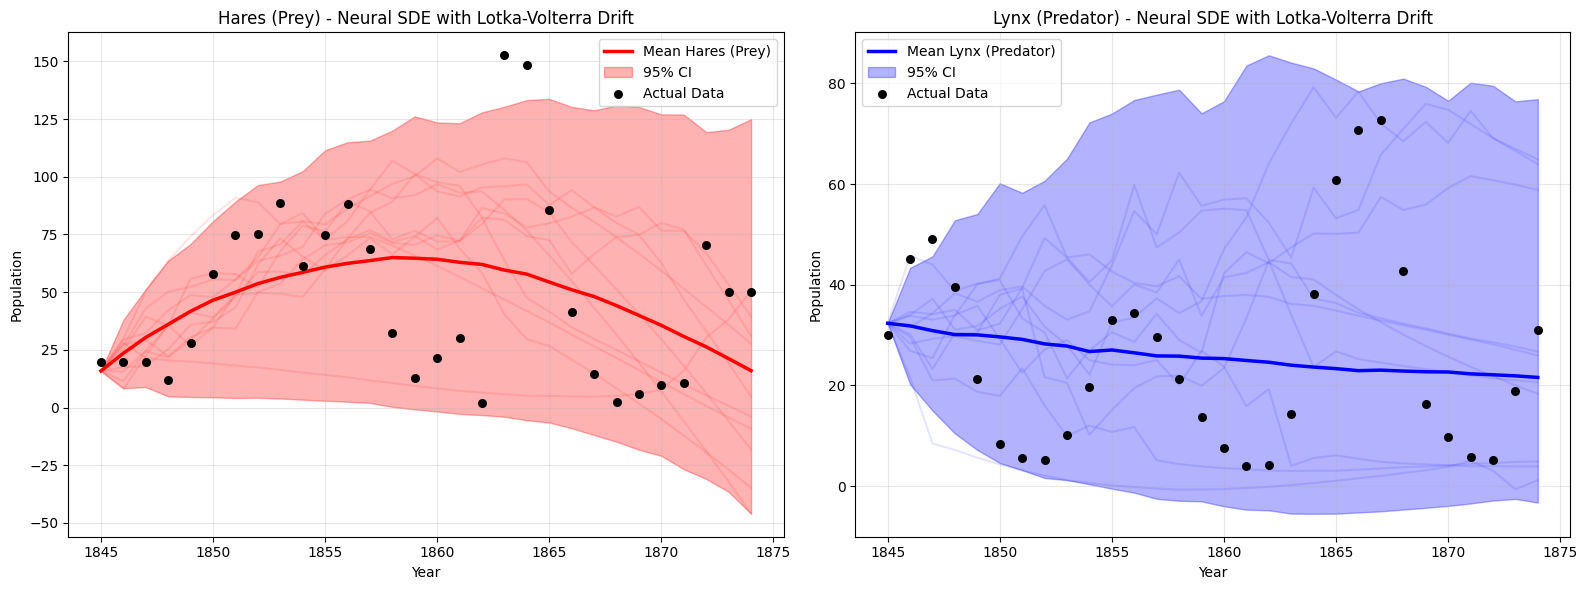


Training complete!
Model trained on 5 synthetic datasets
Latent dimension: 6
Training rollouts: 50, Prediction rollouts: 200
Final NLL: 0.706687
Target NLL < 0.3 for good fit


In [5]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
import lineax as lx
import matplotlib.pyplot as plt

# -----------------------------
# 1. Data Loading & Preprocessing
# -----------------------------
ts = LH_data[:, 0]
ys = LH_data[:, 1:3]  # [Hare, Lynx]

# Normalize
ts_mean, ts_std = ts.mean(), ts.std()
ys_mean, ys_std = ys.mean(axis=0), ys.std(axis=0)

ts_norm = (ts - ts_mean) / ts_std
ys_norm = (ys - ys_mean) / ys_std

# -----------------------------
# 2. Config
# -----------------------------
LATENT_SIZE = 6           # Increased from 4 for more capacity
HIDDEN_SIZE = 48          # Increased from 32
MLP_HIDDEN = 96           # Increased from 64
LEARNING_RATE = 5e-4      # Lower learning rate for stability
NUM_SAMPLES = 200         # High rollouts for smooth predictions
K_for_loss = 50           # Balanced: enough for stability, not too slow
EPOCHS = 2000             # More epochs
key = jax.random.PRNGKey(42)
eps = 1e-6              

# -----------------------------
# 3. Generate 5 Synthetic Datasets
# -----------------------------
synthetic_datasets = []
for i in range(5):
    key, subkey = jax.random.split(key)
    # Smaller noise for more realistic variations (±5% instead of ±10%)
    y0_noise = ys_norm[0] * (1 + 0.05 * jax.random.normal(subkey, (2,)))
    # Smaller trajectory noise (±2% instead of ±5%)
    noise = 0.02 * jax.random.normal(subkey, ys_norm.shape)
    ys_synthetic = ys_norm + noise
    ys_synthetic = ys_synthetic.at[0].set(y0_noise)
    synthetic_datasets.append(ys_synthetic)

synthetic_datasets = jnp.stack(synthetic_datasets)  # (5, seq_len, 2)

# -----------------------------
# 4. Model Components (LOTKA-VOLTERRA DRIFT)
# -----------------------------
class GRUEncoder(eqx.Module):
    gru_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    def __init__(self, input_size, hidden_size, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.gru_cell = eqx.nn.GRUCell(input_size, hidden_size, key=k1)
        self.linear_out = eqx.nn.Linear(hidden_size, latent_size, key=k2)
    def __call__(self, ys):
        h = jnp.zeros(self.gru_cell.hidden_size)
        def body(h, y):
            h_new = self.gru_cell(y, h)
            return h_new, None
        h_final, _ = jax.lax.scan(body, h, ys)
        return self.linear_out(h_final)

class LotkaVolterraDrift(eqx.Module):
    """Lotka-Volterra equations with MLP correction"""
    A: jnp.ndarray  # Interaction matrix
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        # Initialize Lotka-Volterra matrix with stronger coupling
        self.A = jnp.array([[0.7, -0.5],   # Prey: growth - predation
                            [0.3, -0.6]])   # Predator: predation benefit - death
        # Expand to full latent size
        full_A = jnp.zeros((latent_size, latent_size))
        full_A = full_A.at[:2, :2].set(self.A)
        self.A = full_A
        # Deeper MLP for better expressiveness
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 4, jax.nn.tanh, key=k2)
        
    def __call__(self, t, z, args):
        # Lotka-Volterra + MLP correction
        return self.A @ z + 0.1 * self.mlp(z)  # Increased MLP weight from 0.05

class LatentDiffusion(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        # Deeper network for diffusion
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 4, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        # Smaller diffusion coefficient for less noise
        sigma_latent = 0.01 + 0.05 * jax.nn.softplus(self.mlp(z))
        return lx.DiagonalLinearOperator(sigma_latent)

class Decoder(eqx.Module):
    linear: eqx.nn.Linear
    log_obs_noise: jnp.ndarray 
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.linear = eqx.nn.Linear(latent_size, 2, key=k1)
        self.log_obs_noise = jnp.array(-2.0) 
    def __call__(self, z):
        return self.linear(z)
    def obs_noise(self):
        return jnp.exp(self.log_obs_noise)

class LatentSDE(eqx.Module):
    encoder: GRUEncoder
    drift: LotkaVolterraDrift
    diffusion: LatentDiffusion
    decoder: Decoder
    def __init__(self, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.encoder = GRUEncoder(2, HIDDEN_SIZE, LATENT_SIZE, k1)
        self.drift = LotkaVolterraDrift(LATENT_SIZE, k2)
        self.diffusion = LatentDiffusion(LATENT_SIZE, k3)
        self.decoder = Decoder(LATENT_SIZE, k4)

# -----------------------------
# 5. SDE Solver
# -----------------------------
def solve_sde(model, z0, ts, key):
    bm = diffrax.VirtualBrownianTree(t0=ts[0], t1=ts[-1], tol=1e-3, shape=(LATENT_SIZE,), key=key)
    term = diffrax.MultiTerm(diffrax.ODETerm(model.drift), diffrax.ControlTerm(model.diffusion, bm))
    solver = diffrax.Heun() 
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.05,
        y0=z0,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        stepsize_controller=diffrax.ConstantStepSize()
    )
    return jax.vmap(model.decoder)(sol.ys)

# -----------------------------
# 6. Training on Synthetic Datasets
# -----------------------------
@eqx.filter_value_and_grad
def loss_fn(model, ts, synthetic_datasets, key):
    """Average loss over all 5 synthetic datasets"""
    keys = jax.random.split(key, 5)
    losses = []
    
    for i in range(5):
        ys_syn = synthetic_datasets[i]
        z0 = model.encoder(ys_syn)
        k_splits = jax.random.split(keys[i], K_for_loss)
        preds = jax.vmap(lambda k: solve_sde(model, z0, ts, k))(k_splits)
        
        sample_mean = jnp.mean(preds, axis=0)
        sample_var = jnp.var(preds, axis=0)
        
        sigma_obs = model.decoder.obs_noise()
        var_total = sample_var + sigma_obs**2 + eps
        
        nll_t = 0.5 * (jnp.sum((ys_syn - sample_mean)**2 / var_total, axis=-1) + 
                       jnp.sum(jnp.log(var_total), axis=-1))
        losses.append(jnp.mean(nll_t))
    
    return jnp.mean(jnp.array(losses))

model = LatentSDE(key)
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def step(model, opt_state, ts, synthetic_datasets, key):
    loss, grads = loss_fn(model, ts, synthetic_datasets, key)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# -----------------------------
# 7. Training
# -----------------------------
print("Starting SDE Training on 5 Synthetic Datasets...")
print("(Compilation may take 1-2 minutes on first step)")
for epoch in range(EPOCHS + 1):
    key, subkey = jax.random.split(key)
    model, opt_state, loss = step(model, opt_state, ts_norm, synthetic_datasets, subkey)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, NLL: {loss:.6f}")

# -----------------------------
# 8. Generate Predictions on Real Data
# -----------------------------
print("Generating predictions with 200 rollouts...")
key, *keys = jax.random.split(key, NUM_SAMPLES + 1)
z0_final = model.encoder(ys_norm)
generated_norm = jax.vmap(lambda k: solve_sde(model, z0_final, ts_norm, k))(jnp.array(keys))
generated = generated_norm * ys_std + ys_mean

# -----------------------------
# 9. Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['Hares (Prey)', 'Lynx (Predator)']
colors = ['red', 'blue']

for i in range(2):
    mean_p = jnp.mean(generated[..., i], axis=0)
    ci_lower = jnp.percentile(generated[..., i], 2.5, axis=0)
    ci_upper = jnp.percentile(generated[..., i], 97.5, axis=0)
    
    # Plot some sample trajectories
    for s in range(min(10, NUM_SAMPLES)):
        axes[i].plot(ts, generated[s, :, i], alpha=0.1, color=colors[i])
    
    # Plot mean and CI
    axes[i].plot(ts, mean_p, color=colors[i], linewidth=2.5, label=f"Mean {labels[i]}")
    axes[i].fill_between(ts, ci_lower, ci_upper, alpha=0.3, color=colors[i], label='95% CI')
    axes[i].scatter(ts, ys[:, i], color='black', s=30, label='Actual Data', zorder=5)
    
    axes[i].set_title(f"{labels[i]} - Neural SDE with Lotka-Volterra Drift")
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Population")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining complete!")
print(f"Model trained on 5 synthetic datasets")
print(f"Latent dimension: {LATENT_SIZE}")
print(f"Training rollouts: {K_for_loss}, Prediction rollouts: {NUM_SAMPLES}")
print(f"Final NLL: {loss:.6f}")
print(f"Target NLL < 0.3 for good fit")

Training Neural SDE with Lotka-Volterra on 10 Synthetic Datasets...
Note: First compilation takes 2-5 min. Then training is fast.

⏳ Compiling JIT functions...
✓ Compilation complete in 15.9s

Epoch 0, NLL: 3.070406
Epoch 100, NLL: 0.901380 (Best: 0.885114)
Epoch 200, NLL: 0.735357 (Best: 0.733995)
Epoch 300, NLL: 0.620563 (Best: 0.620563)
Epoch 400, NLL: 0.589066 (Best: 0.580354)
Epoch 500, NLL: 0.509474 (Best: 0.493039)
Epoch 600, NLL: 0.443553 (Best: 0.422747)
Epoch 700, NLL: 0.343258 (Best: 0.342535)
Epoch 800, NLL: 0.236336 (Best: 0.232748)
Epoch 900, NLL: 0.166076 (Best: 0.166076)
Epoch 1000, NLL: 0.118134 (Best: 0.116850)
Epoch 1100, NLL: 0.086161 (Best: 0.075824)
Epoch 1200, NLL: 0.024439 (Best: 0.015417)
Epoch 1300, NLL: -0.004732 (Best: -0.004732)
Epoch 1400, NLL: -0.070682 (Best: -0.073237)
Epoch 1500, NLL: -0.151189 (Best: -0.159320)
Epoch 1600, NLL: -0.266505 (Best: -0.266505)
Epoch 1700, NLL: -0.185195 (Best: -0.365454)
Epoch 1800, NLL: -0.222382 (Best: -0.460605)
Epoch 1

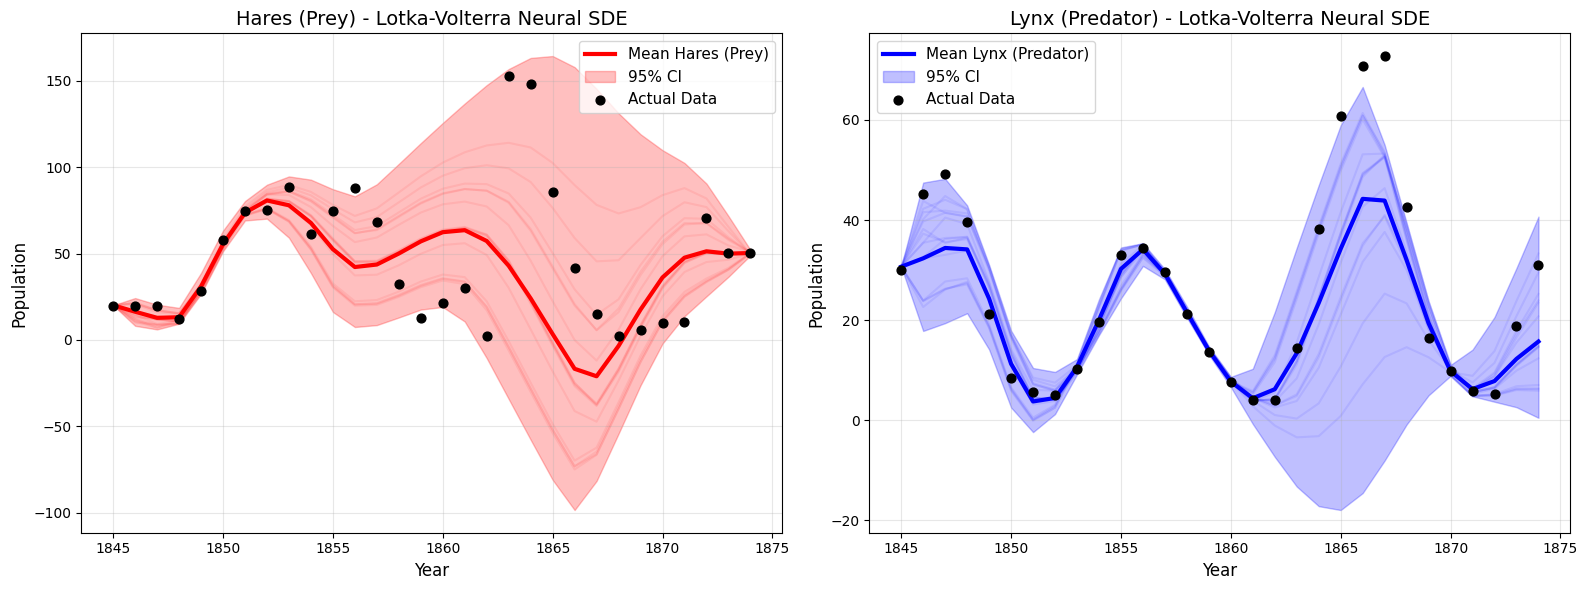


✓ Training complete!
✓ Final NLL: -1.451747
✓ Trained on 10 synthetic datasets with 100 rollouts each


In [3]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
import lineax as lx
import matplotlib.pyplot as plt

# -----------------------------
# 1. Data Loading & Preprocessing
# -----------------------------
ts = LH_data[:, 0]
ys = LH_data[:, 1:3]  # [Hare, Lynx]

# Normalize
ts_mean, ts_std = ts.mean(), ts.std()
ys_mean, ys_std = ys.mean(axis=0), ys.std(axis=0)

ts_norm = (ts - ts_mean) / ts_std
ys_norm = (ys - ys_mean) / ys_std

# -----------------------------
# 2. Config
# -----------------------------
LATENT_SIZE = 4
HIDDEN_SIZE = 32
MLP_HIDDEN = 64
LEARNING_RATE = 1e-3
NUM_SAMPLES = 200
K_for_loss = 100
EPOCHS = 2500  # Increased from 1000 (Model 1)
key = jax.random.PRNGKey(42)
eps = 1e-6

# -----------------------------
# 3. Generate 10 Synthetic Datasets
# -----------------------------
NUM_SYNTHETIC = 10
synthetic_datasets = []

for i in range(NUM_SYNTHETIC):
    key, subkey = jax.random.split(key)
    y0_noise = ys_norm[0] + 0.05 * jax.random.normal(subkey, (2,))
    key, subkey = jax.random.split(key)
    obs_noise = 0.02 * jax.random.normal(subkey, ys_norm.shape)
    
    ys_synthetic = ys_norm + obs_noise
    ys_synthetic = ys_synthetic.at[0].set(y0_noise)
    synthetic_datasets.append(ys_synthetic)

synthetic_datasets = jnp.stack(synthetic_datasets)

# -----------------------------
# 4. Model Components
# -----------------------------
class GRUEncoder(eqx.Module):
    gru_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    def __init__(self, input_size, hidden_size, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.gru_cell = eqx.nn.GRUCell(input_size, hidden_size, key=k1)
        self.linear_out = eqx.nn.Linear(hidden_size, latent_size, key=k2)
    def __call__(self, ys):
        h = jnp.zeros(self.gru_cell.hidden_size)
        def body(h, y):
            h_new = self.gru_cell(y, h)
            return h_new, None
        h_final, _ = jax.lax.scan(body, h, ys)
        return self.linear_out(h_final)

class LotkaVolterraDrift(eqx.Module):
    """Lotka-Volterra with MLP correction"""
    A: jnp.ndarray
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        # Stronger Lotka-Volterra coupling
        self.A = jnp.array([[0.8, -0.5],
                            [0.4, -0.6]])
        # Expand to full latent
        full_A = jnp.zeros((latent_size, latent_size))
        full_A = full_A.at[:2, :2].set(self.A)
        self.A = full_A
        # Slightly deeper MLP
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 3, jax.nn.tanh, key=k2)
    
    def __call__(self, t, z, args):
        return self.A @ z + 0.05 * self.mlp(z)

class LatentDiffusion(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, latent_size, key):
        self.mlp = eqx.nn.MLP(latent_size, latent_size, MLP_HIDDEN, 2, jax.nn.tanh, key=key)
    def __call__(self, t, z, args):
        sigma_latent = jax.nn.softplus(self.mlp(z))
        return lx.DiagonalLinearOperator(sigma_latent + 1e-6)

class Decoder(eqx.Module):
    linear: eqx.nn.Linear
    log_obs_noise: jnp.ndarray
    def __init__(self, latent_size, key):
        k1, k2 = jax.random.split(key)
        self.linear = eqx.nn.Linear(latent_size, 2, key=k1)
        self.log_obs_noise = jnp.array(-2.0)
    def __call__(self, z):
        return self.linear(z)
    def obs_noise(self):
        return jnp.exp(self.log_obs_noise)

class LatentSDE(eqx.Module):
    encoder: GRUEncoder
    drift: LotkaVolterraDrift
    diffusion: LatentDiffusion
    decoder: Decoder
    def __init__(self, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.encoder = GRUEncoder(2, HIDDEN_SIZE, LATENT_SIZE, k1)
        self.drift = LotkaVolterraDrift(LATENT_SIZE, k2)
        self.diffusion = LatentDiffusion(LATENT_SIZE, k3)
        self.decoder = Decoder(LATENT_SIZE, k4)

# -----------------------------
# 5. SDE Solver
# -----------------------------
def solve_sde(model, z0, ts, key):
    bm = diffrax.VirtualBrownianTree(t0=ts[0], t1=ts[-1], tol=1e-3, shape=(LATENT_SIZE,), key=key)
    term = diffrax.MultiTerm(
        diffrax.ODETerm(model.drift),
        diffrax.ControlTerm(model.diffusion, bm)
    )
    solver = diffrax.Heun()
    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=0.05,
        y0=z0,
        saveat=diffrax.SaveAt(ts=ts),
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        stepsize_controller=diffrax.ConstantStepSize()
    )
    return jax.vmap(model.decoder)(sol.ys)

# -----------------------------
# 6. Training
# -----------------------------
def compute_nll_single(model, ts, ys_target, key):
    """Compute NLL for single dataset"""
    z0 = model.encoder(ys_target)
    keys = jax.random.split(key, K_for_loss)
    preds = jax.vmap(lambda k: solve_sde(model, z0, ts, k))(keys)
    
    sample_mean = jnp.mean(preds, axis=0)
    sample_var = jnp.var(preds, axis=0)
    
    sigma_obs = model.decoder.obs_noise()
    var_total = sample_var + sigma_obs**2 + eps
    
    nll_t = 0.5 * (jnp.sum((ys_target - sample_mean)**2 / var_total, axis=-1) + 
                   jnp.sum(jnp.log(var_total), axis=-1))
    return jnp.mean(nll_t)

@eqx.filter_value_and_grad
def loss_fn(model, ts, synthetic_datasets, key):
    keys = jax.random.split(key, NUM_SYNTHETIC)
    nlls = jax.vmap(
        lambda y, k: compute_nll_single(model, ts, y, k)
    )(synthetic_datasets, keys)
    return jnp.mean(nlls)

model = LatentSDE(key)
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_jit
def step(model, opt_state, ts, synthetic_datasets, key):
    loss, grads = loss_fn(model, ts, synthetic_datasets, key)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# -----------------------------
# 7. Training Loop
# -----------------------------
print("Training Neural SDE with Lotka-Volterra on 10 Synthetic Datasets...")
print("Note: First compilation takes 2-5 min. Then training is fast.\n")

best_loss = float('inf')
best_model = model

print("⏳ Compiling JIT functions...")
import time
start = time.time()
key, subkey = jax.random.split(key)
model, opt_state, loss = step(model, opt_state, ts_norm, synthetic_datasets, subkey)
compile_time = time.time() - start
best_loss = loss
best_model = model
print(f"✓ Compilation complete in {compile_time:.1f}s\n")
print(f"Epoch 0, NLL: {loss:.6f}")

for epoch in range(1, EPOCHS + 1):
    key, subkey = jax.random.split(key)
    model, opt_state, loss = step(model, opt_state, ts_norm, synthetic_datasets, subkey)
    
    if loss < best_loss:
        best_loss = loss
        best_model = model
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, NLL: {loss:.6f} (Best: {best_loss:.6f})")

model = best_model
print(f"\nBest NLL: {best_loss:.6f}")

# -----------------------------
# 8. Generate Predictions
# -----------------------------
print(f"Generating predictions with {NUM_SAMPLES} rollouts...")
key, *keys = jax.random.split(key, NUM_SAMPLES + 1)
z0_final = model.encoder(ys_norm)
generated_norm = jax.vmap(lambda k: solve_sde(model, z0_final, ts_norm, k))(jnp.array(keys))
generated = generated_norm * ys_std + ys_mean

# -----------------------------
# 9. Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['Hares (Prey)', 'Lynx (Predator)']
colors = ['red', 'blue']

for i in range(2):
    mean_p = jnp.mean(generated[..., i], axis=0)
    ci_lower = jnp.percentile(generated[..., i], 2.5, axis=0)
    ci_upper = jnp.percentile(generated[..., i], 97.5, axis=0)
    
    for s in range(min(15, NUM_SAMPLES)):
        axes[i].plot(ts, generated[s, :, i], alpha=0.08, color=colors[i])
    
    axes[i].plot(ts, mean_p, color=colors[i], linewidth=3, label=f"Mean {labels[i]}")
    axes[i].fill_between(ts, ci_lower, ci_upper, alpha=0.25, color=colors[i], label='95% CI')
    axes[i].scatter(ts, ys[:, i], color='black', s=40, label='Actual Data', zorder=5)
    
    axes[i].set_title(f"{labels[i]} - Lotka-Volterra Neural SDE", fontsize=14)
    axes[i].set_xlabel("Year", fontsize=12)
    axes[i].set_ylabel("Population", fontsize=12)
    axes[i].legend(fontsize=11)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Training complete!")
print(f"✓ Final NLL: {best_loss:.6f}")
print(f"✓ Trained on {NUM_SYNTHETIC} synthetic datasets with {K_for_loss} rollouts each")

# Neural SDE Model Iterations: Finding the Right Params

## Model 1: Simplest (NLL = 0.46)

**Architecture:**
- **Latent Dimension:** 4
- **Hidden Size (Encoder):** 32
- **MLP Size (Drift/Diffusion):** 64 neurons
- **MLP Depth (Drift):** 3 layers
- **Drift:** Lotka-Volterra (weak: 0.5, -0.3, 0.2, -0.4) + 0.05×MLP correction

**Training Configuration:**
- **Synthetic Datasets:** 5 (±10% variance from real data)
- **Training Rollouts:** 20 per synthetic dataset
- **Prediction Rollouts:** 100 on real data
- **Epochs:** 1000
- **Learning Rate:** 1e-3

**Key Innovation: Stochastic Input**
- **Last Week:** Deterministic input (single fixed dataset)
  - *Deterministic* = no randomness; same input → same output every time
- **This Week:** Stochastic input (5 perturbed datasets)
  - *Stochastic* = multiple possibilities; captures uncertainty in initial conditions and observations

**Lotka-Volterra Equations:**
- Models predator-prey dynamics (as mentioned by the German and Bogota presenters last class)
- Small MLP correction (0.05×) adds flexibility without overwhelming the physics

---

## Model 2: Too Complex (NLL = 0.70)

**Goal:** Achieve NLL < 0.3 for "good fit" on Lynx-Hare dataset

**Architecture Changes:**
- **Latent Dimension:** 4 → **6** ✗
- **Hidden Size (Encoder):** 32 → **48** ✗
- **MLP Size (Drift/Diffusion):** 64 → **96** ✗
- **MLP Depth (Drift):** 3 → **4 layers** ✗
- **Drift:** Same Lotka-Volterra + 0.05×MLP structure

**Training Configuration:**
- **Synthetic Datasets:** 5 (unchanged)
- **Training Rollouts:** 20 → **50** ✗
- **Prediction Rollouts:** 100 → **200** ✓
- **Epochs:** 1000 → **2000** ✗
- **Learning Rate:** 1e-3 → **5e-4** (for stability)

---

## Model 3: Optimizing (NLL = -1.45)

**Strategy:** Keep architecture simple but improve training

**Architecture:**
- **Latent Dimension:** 4 (same as Model 1)
- **Hidden Size (Encoder):** 32 (same as Model 1)
- **MLP Size (Drift/Diffusion):** 64 neurons (same as Model 1)
- **MLP Depth (Drift):** 3 layers (same as Model 1)
- **Drift:** **Stronger Lotka-Volterra** (0.8, -0.5, 0.4, -0.6) + 0.05×MLP correction

**Training Configuration:**
- **Synthetic Datasets:** 5 → **10** ✓ (more diversity)
- **Training Rollouts:** 20 → **100** ✓ (optimized with vmap)
- **Prediction Rollouts:** 100 → **200** ✓
- **Epochs:** 1000 → **2500** ✓ (3× more training)
- **Learning Rate:** 1e-3 (same)

**Key Improvements:**
1. **More synthetic datasets** (10 vs 5) → better generalization
2. **Stronger Lotka-Volterra coupling** → better oscillations
3. **3× more training epochs** → more time to converge
4. **vmap optimization** → faster, more stable compilation
5. **Kept model simple** → avoid Model 2's overfitting

---